In [128]:
pip install dash-ag-grid

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 40.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [126]:
import requests
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

In [68]:
wages = pd.read_csv("./City_of_Seattle_Wage_Data_20260402.csv")



In [69]:
wages.head()

,Department,Last Name,First Name,Job Title,Hourly Rate
0,Seattle Police Department,Aagard,Lori,Executive 4,$150.43
1,Seattle City Light,Aaltonen,Evan,Powerline Clear Tree Trimmer,$61.52
2,Seattle Public Utilities,Aar,Abdimallik,"Civil Engineering Specialist,Senior",$70.35
3,Seattle Department of Transportation,Abad,Abigail,Administrative Specialist II-BU,$41.31
4,Human Services,Aba-Husain,Adam,"Grants and Contracts Specialist,Senior",$50.33


In [70]:
wages.columns

Index(['Department', 'Last Name', 'First Name', 'Job Title', 'Hourly Rate '], dtype='object')

In [73]:
wages = wages.rename(columns={"Hourly Rate ": "Hourly Rate"})
wages = wages.rename(str.lower, axis=1)

In [74]:
wages.columns

Index(['department', 'last name', 'first name', 'job title', 'hourly rate'], dtype='object')

In [75]:
wages.dtypes

department     object
last name      object
first name     object
job title      object
hourly rate    object
dtype: object

In [77]:
wages['hourly rate'] = wages['hourly rate'].str.strip("$")

In [93]:
wages['hourly rate'] = wages['hourly rate'].astype("float64")
wages['salary estimate'] = wages['hourly rate'] * 2080

In [91]:
wages.dtypes

department          object
last name           object
first name          object
job title           object
hourly rate        float64
salary estimate    float64
dtype: object

In [92]:
wages.sort_values(by=["hourly rate"], ascending=False)

,department,last name,first name,job title,hourly rate,salary estimate
7334,Seattle City Light,Lindell,Dawn,City Light General Manager & CEO,254.79,529963.2
8245,Seattle City Light,McLerran,Dennis,"Electric Utility Executive 3,Officer",186.65,388232.0
11086,Seattle Fire Department,Scoggins,Harold,Fire Chief,179.55,373464.0
7114,Seattle Public Utilities,Lee,Andrew,SPU General Manager & CEO,179.55,373464.0
793,Seattle Police Department,Barnes,Shon,Seattle Police Chief,179.54,373443.2
...,...,...,...,...,...,...
10855,Parks and Recreation Department,Samassa,Aisha,High School Intern,21.51,44740.8
6358,Parks and Recreation Department,Karlan,Ryan,Work Training Enrollee,21.51,44740.8
3646,Parks and Recreation Department,Elmi,Sumaya,High School Intern,21.51,44740.8
9919,Parks and Recreation Department,Pittenger,Michael,Work Training Enrollee,21.51,44740.8


In [101]:
wages

,department,last name,first name,job title,hourly rate,salary estimate
0,Seattle Police Department,Aagard,Lori,Executive 4,150.43,312894.4
1,Seattle City Light,Aaltonen,Evan,Powerline Clear Tree Trimmer,61.52,127961.6
2,Seattle Public Utilities,Aar,Abdimallik,"Civil Engineering Specialist,Senior",70.35,146328.0
3,Seattle Department of Transportation,Abad,Abigail,Administrative Specialist II-BU,41.31,85924.8
4,Human Services,Aba-Husain,Adam,"Grants and Contracts Specialist,Senior",50.33,104686.4
...,...,...,...,...,...,...
13859,Seattle Department of Transportation,Zuniga,Rafael,"Management Systems Analyst,Senior",65.54,136323.2
13860,Information Technology,Zuniga,Roy,Information Technology Professional B BU,76.60,159328.0
13861,Seattle Public Utilities,Zurowski,Allan,Carpenter,51.12,106329.6
13862,Seattle Police Department,Zwaschka,Andrew,Police Sergeant-Detective-Homicide,90.10,187408.0


In [109]:
avg_wage = wages[['department','hourly rate','salary estimate']].groupby(['department']).mean().sort_values('hourly rate', ascending=False)

avg_wage

,hourly rate,salary estimate
department,,
Police Relief and Pension,89.070000,185265.600000
Mayor's Office,85.282128,177386.825532
Intergovernmental Relations,78.227500,162713.200000
City Budget Office,77.950556,162137.155556
City Auditor's Office,76.818571,159782.628571
Information Technology,76.150315,158392.655692
Economic and Revenue Forecasts,74.450000,154856.000000
Community Police Commission,71.500000,148720.000000
Hearing Examiner,69.742000,145063.360000


In [113]:
wages['job title'].unique().shape

(1181,)

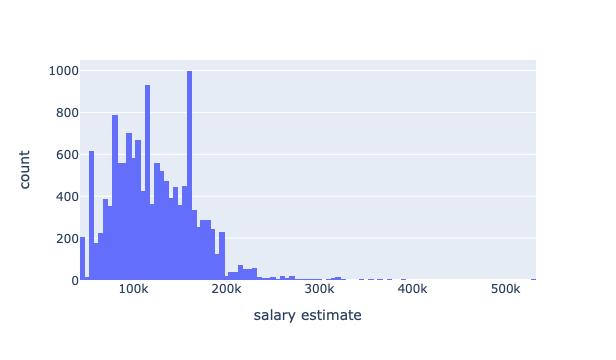

In [117]:
px.histogram(wages, x='salary estimate', nbins=100)

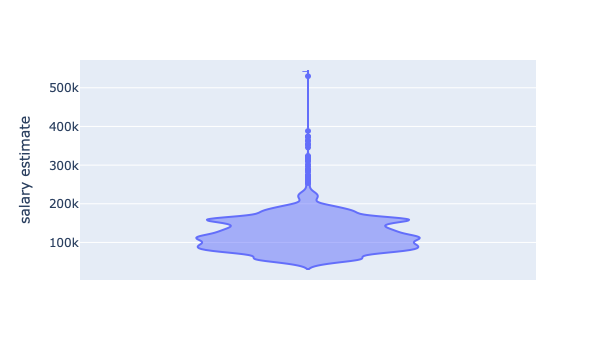

In [119]:
px.violin(wages, y="salary estimate")

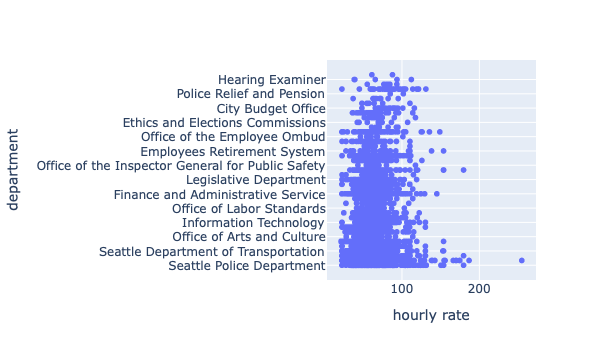

In [121]:
px.scatter(wages, x='hourly rate',y='department')

In [124]:
over200k = wages[wages['salary estimate'] > 200000]

In [127]:
#px.scatter(wages, x='hourly rate',y='department', color='department')